In [3]:
%pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [4]:
import yfinance as yf
data = yf.download(["^GSPC", "^VIX"], start="2010-01-01")["Close"]
print(data.tail())

[*********************100%***********************]  2 of 2 completed

Ticker            ^GSPC   ^VIX
Date                          
2026-07-15  7572.399902  15.67
2026-07-16  7533.770020  16.73
2026-07-17  7457.689941  18.77
2026-07-20  7443.279785  18.65
2026-07-21  7510.419922  17.01


In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
spx = data["^GSPC"]

In [7]:
log_returns = np.log(spx / spx.shift(1))

In [8]:
realized_vol = log_returns.rolling(21).std() * np.sqrt(252)

In [9]:
vix = data["^VIX"] / 100

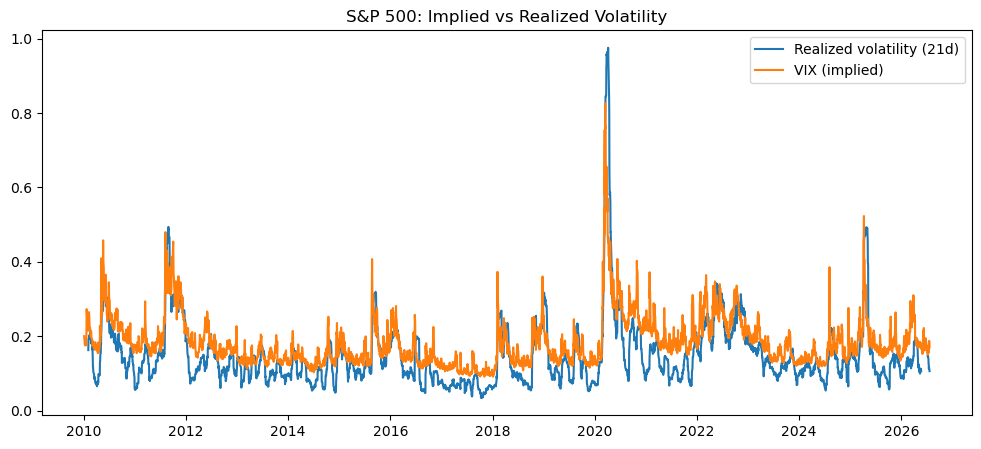

In [10]:
plt.figure(figsize=(12, 5))
plt.plot(realized_vol, label="Realized volatility (21d)")
plt.plot(vix, label="VIX (implied)")
plt.legend()
plt.title("S&P 500: Implied vs Realized Volatility")
plt.show()

In [27]:
S = 7471       # current S&P level
K = 7471       
T = 30/365     # 30 days
r = 0.04
sigma = 0.1775 # today's VIX as a decimal

In [28]:
from scipy.stats import norm

def black_scholes(S, K, T, r, sigma, option_type="call"):
    d1 = (np.log(S / K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    if option_type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    return price

In [29]:
call = black_scholes(S, K, T, r, sigma, "call")
put  = black_scholes(S, K, T, r, sigma, "put")
print("Call:", call)
print("Put:", put)

Call: 163.98206775586232
Put: 139.4602079691549


In [30]:
print("Call - Put:", call - put)
print("S - K*e^(-rT):", S - K * np.exp(-r * T))

Call - Put: 24.52185978670741
S - K*e^(-rT): 24.521859786706955


In [31]:
from scipy.optimize import brentq

def implied_vol(market_price, S, K, T, r, option_type="call"):
    def difference(sigma):
        return black_scholes(S, K, T, r, sigma, option_type) - market_price
    return brentq(difference, 0.001, 5.0)

In [32]:
recovered = implied_vol(163.98, S, K, T, r, "call")
print(recovered)

0.1774975702749444


In [33]:
spy = yf.Ticker("SPY")
expirations = spy.options
print(expirations)

('2026-07-21', '2026-07-22', '2026-07-23', '2026-07-24', '2026-07-27', '2026-07-28', '2026-07-29', '2026-07-30', '2026-07-31', '2026-08-07', '2026-08-14', '2026-08-21', '2026-08-28', '2026-08-31', '2026-09-18', '2026-09-30', '2026-10-16', '2026-10-30', '2026-11-20', '2026-11-30', '2026-12-18', '2026-12-31', '2027-01-15', '2027-03-19', '2027-03-31', '2027-06-17', '2027-06-30', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15')


In [34]:
expiry = "2026-08-21"
chain = spy.option_chain(expiry)
calls = chain.calls
puts = chain.puts

print(calls.shape, puts.shape)
calls.head()

(239, 14) (212, 14)


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY260821C00360000,2026-07-20 13:53:38+00:00,360.0,387.95,388.03,391.31,0.00000,0.000000,1.0,207,1.190922,True,REGULAR,USD
1,SPY260821C00365000,2026-07-20 13:53:38+00:00,365.0,383.06,383.05,386.33,0.00000,0.000000,1.0,144,1.173344,True,REGULAR,USD
2,SPY260821C00370000,2026-07-21 18:43:44+00:00,370.0,379.50,377.89,381.40,35.51999,10.326179,3.0,3,1.146733,True,REGULAR,USD
3,SPY260821C00375000,2026-04-07 19:20:29+00:00,375.0,288.49,363.80,367.00,0.00000,0.000000,NaN,0,0.000010,True,REGULAR,USD
4,SPY260821C00380000,2026-07-10 14:36:09+00:00,380.0,372.60,368.06,371.42,0.00000,0.000000,NaN,0,1.120122,True,REGULAR,USD


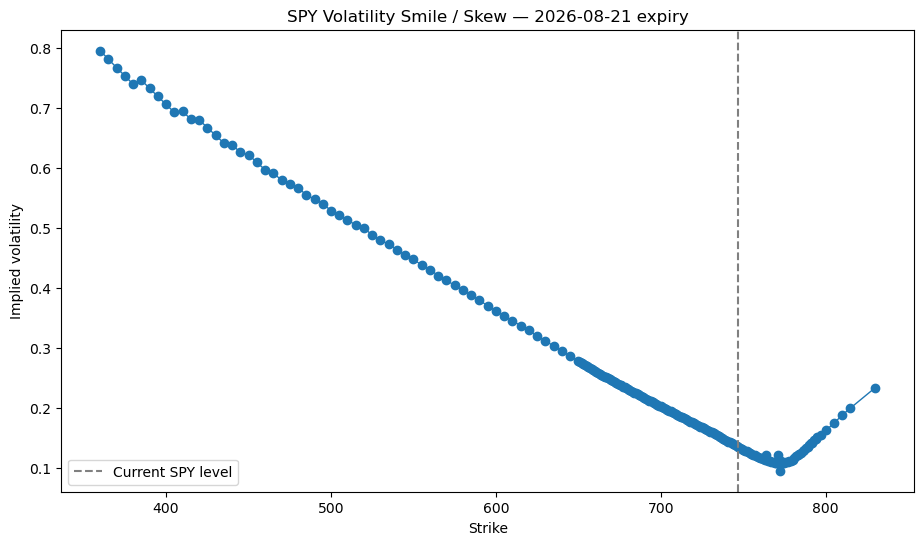

In [35]:
import pandas as pd

S_spy = 747.0          
r = 0.04
T = 31/365         

puts = puts.copy()
puts["mid"] = (puts["bid"] + puts["ask"]) / 2
liquid = puts[(puts["bid"] > 0) & (puts["mid"] > 0)]

results = []
for _, row in liquid.iterrows():
    K = row["strike"]
    price = row["mid"]
    try:
        iv = implied_vol(price, S_spy, K, T, r, "put")
        results.append((K, iv))
    except Exception:
        pass   

strikes = [k for k, iv in results]
ivs     = [iv for k, iv in results]

plt.figure(figsize=(11, 6))
plt.plot(strikes, ivs, marker="o", linewidth=1)
plt.axvline(S_spy, color="grey", linestyle="--", label="Current SPY level")
plt.xlabel("Strike")
plt.ylabel("Implied volatility")
plt.title("SPY Volatility Smile / Skew — 2026-08-21 expiry")
plt.legend()
plt.show()

In [36]:
daily_ret = np.log(spx / spx.shift(1)).dropna()

In [37]:
monthly_realized_var = daily_ret.groupby(daily_ret.index.to_period("M")).var() * 252

In [38]:
vix_dec = data["^VIX"] / 100
monthly_implied_var = vix_dec.groupby(vix_dec.index.to_period("M")).first() ** 2

In [39]:
vrp = (monthly_implied_var - monthly_realized_var).dropna()

In [40]:
print("Number of months:", len(vrp))
print("% of months profitable:", (vrp > 0).mean() * 100)
print("Average monthly P&L:", vrp.mean())
print("Worst month:", vrp.min(), "on", vrp.idxmin())
print("Best month:", vrp.max(), "on", vrp.idxmax())

Number of months: 199
% of months profitable: 84.42211055276381
Average monthly P&L: 0.008967819682820751
Worst month: -0.7754293159690886 on 2020-03
Best month: 0.15790979123207052 on 2020-04


Final equity (from 1.0): 2.14
Annualized Sharpe ratio: 0.49
Maximum drawdown: -39.7 %


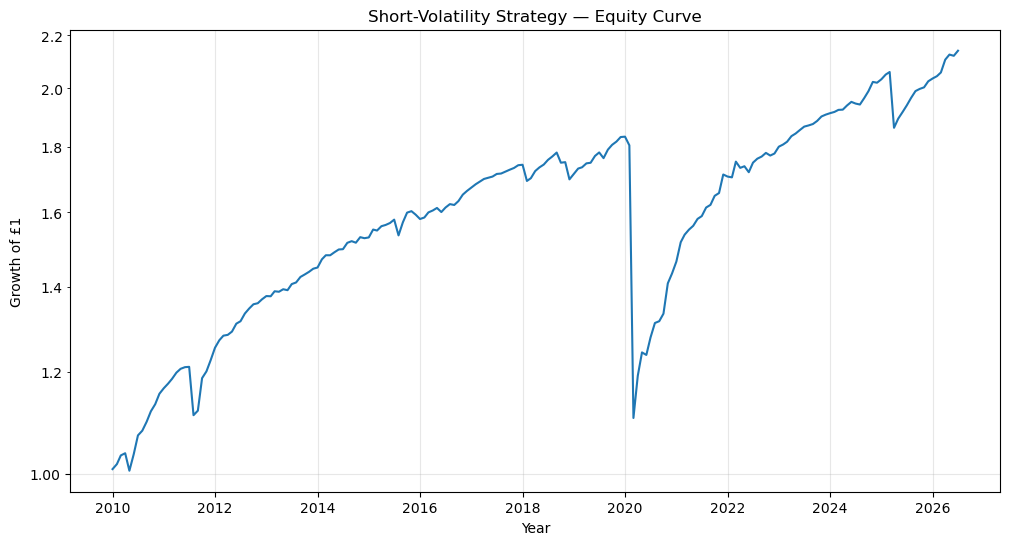

In [41]:
# scale variance P&L into realistic monthly returns
from matplotlib.ticker import ScalarFormatter
scaling = 0.5
monthly_return = vrp * scaling

# equity curve: start at 1, compound each month
equity = (1 + monthly_return).cumprod()

# annualized Sharpe ratio (12 months per year)
sharpe = (monthly_return.mean() / monthly_return.std()) * np.sqrt(12)

# maximum drawdown
running_max = equity.cummax()
drawdown = (equity - running_max) / running_max
max_dd = drawdown.min()

print("Final equity (from 1.0):", round(equity.iloc[-1], 2))
print("Annualized Sharpe ratio:", round(sharpe, 2))
print("Maximum drawdown:", round(max_dd * 100, 1), "%")

# plot the equity curve
equity.index = equity.index.to_timestamp()
plt.figure(figsize=(12, 6))
plt.plot(equity)
plt.title("Short-Volatility Strategy — Equity Curve")
plt.ylabel("Growth of £1")
plt.xlabel("Year")
plt.yscale("log")
ax = plt.gca()
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_minor_formatter(ScalarFormatter())
plt.grid(True, alpha=0.3)
plt.show()

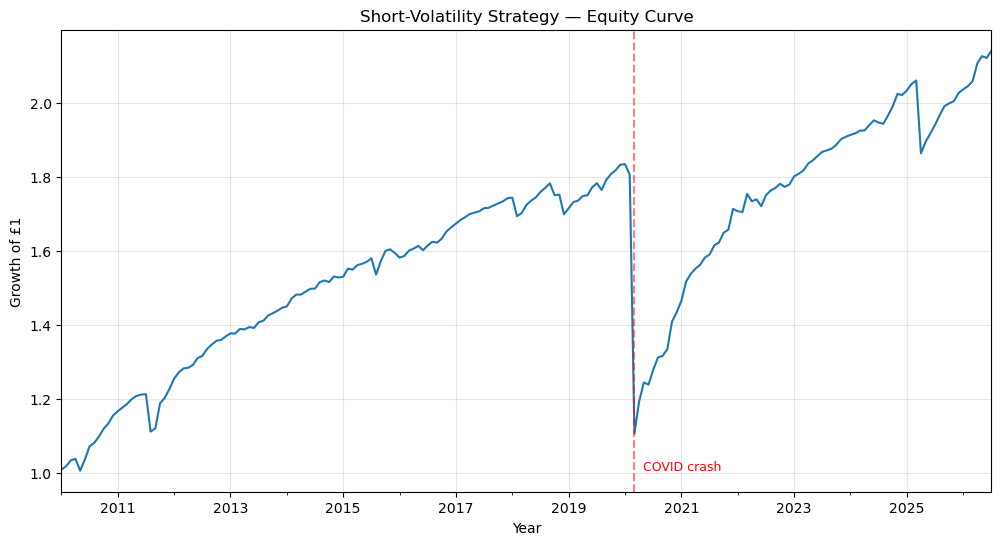

In [42]:
ax = equity.plot(figsize=(12, 6), title="Short-Volatility Strategy — Equity Curve")
ax.axvline(pd.Timestamp("2020-03-01"), color="red", linestyle="--", alpha=0.5)
ax.text(pd.Timestamp("2020-04-01"), equity.min(), " COVID crash", color="red", fontsize=9)
plt.ylabel("Growth of £1")
plt.xlabel("Year")
plt.grid(True, alpha=0.3)
plt.savefig("equity_curve.png", dpi=150, bbox_inches="tight")
plt.show()